In [83]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE, Isomap, MDS
import umap
import matplotlib.patches as mpatches
from scipy.stats import entropy

In [84]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_SYMBOLIC = PROJECT_ROOT / "data" / "symbolic"
DATA_SYMBOLIC.mkdir(parents=True, exist_ok=True)

DATA_CLUSTER = PROJECT_ROOT / "data" / "cluster"
DATA_CLUSTER.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", DATA_CLUSTER)

Processed data folder: c:\Users\ccana\Documents\Doutorado\VISEMTracking\data\cluster


In [85]:
df_processed = pd.read_csv(DATA_SYMBOLIC / "01_symbolic.csv")
df = pd.read_csv(DATA_SYMBOLIC / "02_symbolic_per_trajectory.csv")

In [86]:
n = 10

def parse_symbolic(s):
    try:
        return ast.literal_eval(s)
    except:
        return []

df['movement_list'] = df[f"symbolic_movement_{n}"].apply(parse_symbolic)
df['movement_list'] = df['movement_list'].apply(
    lambda seq: [s for s in seq if s != '']
)

Identificação dos Estados Únicos

In [87]:
all_states = set()
for seq in df['movement_list']:
    all_states.update(seq)

unique_states = sorted(list(all_states))
state_to_idx = {state: i for i, state in enumerate(unique_states)}
n_states = len(unique_states)
print(f"Número de estados identificados: {n_states}")


Número de estados identificados: 20


Cálculo da Matriz de Markov por Trajetória

In [88]:
transition_matrices = []
markov_matrices = []

for seq in df['movement_list']:
    # Inicializa matriz de contagem
    matrix = np.zeros((n_states, n_states))
    
    # Contagem de transições
    if len(seq) > 1:
        for i in range(len(seq) - 1):
            current_state = seq[i]
            next_state = seq[i+1]
            r = state_to_idx[current_state]
            c = state_to_idx[next_state]
            matrix[r, c] += 1
            
    # Normalização (Contagem -> Probabilidade)
    row_sums = matrix.sum(axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        prob_matrix = matrix / row_sums[:, np.newaxis]
    prob_matrix = np.nan_to_num(prob_matrix) # Trata divisões por zero
    
    # Linearização para vetor de características
    transition_matrices.append(prob_matrix.flatten())
    markov_matrices.append(prob_matrix)
X = np.array(transition_matrices)

Agrupamento (Clustering) com K-Means

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)
df['cluster'] = clusters

Métricas de Insights

In [90]:
# C. Métricas de Insight
# Entropia
def calculate_entropy(seq):
    if not seq: return 0
    _, counts = np.unique(seq, return_counts=True)
    return entropy(counts, base=2)

# Dwell Time
def avg_dwell_time(seq):
    if not seq: return 0
    dwells = []
    curr_dwell = 1
    for i in range(1, len(seq)):
        if seq[i] == seq[i-1]:
            curr_dwell += 1
        else:
            dwells.append(curr_dwell)
            curr_dwell = 1
    dwells.append(curr_dwell)
    return np.mean(dwells)

# Ratio de Velocidade
def high_speed_ratio(seq):
    count = sum(1 for s in seq if 'Rapido' in str(s))
    return count / len(seq) if seq else 0

df['shannon_entropy'] = df['movement_list'].apply(calculate_entropy)
df['avg_dwell_time'] = df['movement_list'].apply(avg_dwell_time)
df['high_speed_ratio'] = df['movement_list'].apply(high_speed_ratio)

Redução de Dimensionalidade

In [91]:
# PCA
df[['pca_1', 'pca_2']] = PCA(n_components=2).fit_transform(X)
# t-SNE
df[['tsne_1', 'tsne_2']] = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)
# Isomap
df[['isomap_1', 'isomap_2']] = Isomap(n_components=2, n_neighbors=15).fit_transform(X)
# MDS
df[['mds_1', 'mds_2']] = MDS(n_components=2, random_state=42, normalized_stress='auto').fit_transform(X)
# NMF
df[['nmf_1', 'nmf_2']] = NMF(n_components=2, init='random', random_state=42, max_iter=500).fit_transform(X)
# UMAP
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1, n_jobs=-1)
X_umap = reducer.fit_transform(X)
df['umap_1'] = X_umap[:, 0]
df['umap_2'] = X_umap[:, 1]


C:\Users\ccana\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


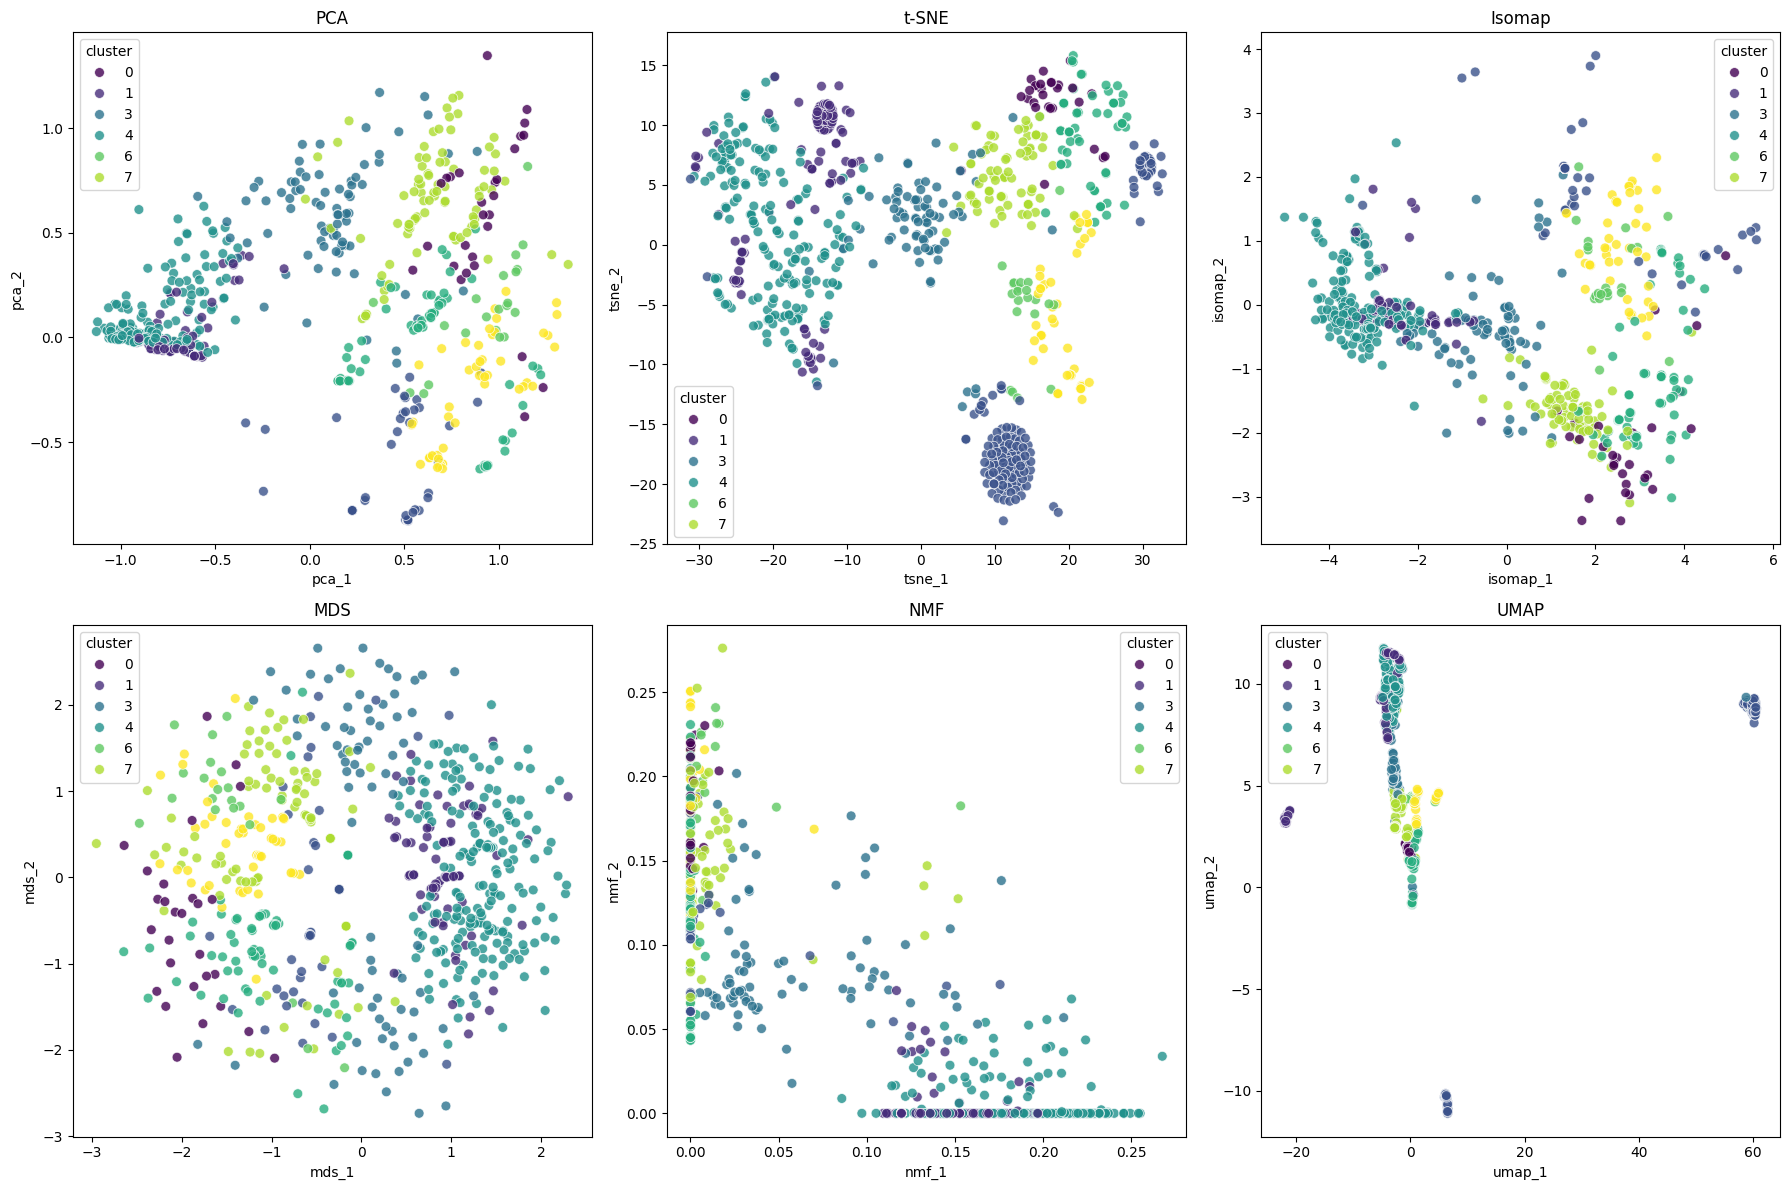

In [92]:
# Plot 1: Projeções
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 12))
axes1 = axes1.flatten()
projections = [
    ('pca', 'PCA'), ('tsne', 't-SNE'), 
    ('isomap', 'Isomap'), ('mds', 'MDS'), ('nmf', 'NMF'), ('umap', 'UMAP')
]

for i, (prefix, title) in enumerate(projections):
    sns.scatterplot(
        data=df, x=f'{prefix}_1', y=f'{prefix}_2', 
        hue='cluster', palette='viridis', s=50, alpha=0.8, ax=axes1[i]
    )
    axes1[i].set_title(title)

#fig1.delaxes(axes1[5]) # Remove o último vazio
plt.tight_layout()
plt.show()

## Métricas de Caracterização do Movimento Celular

### 1. Entropia de Shannon *(Complexidade)*
Mede o quão **imprevisível** ou **diverso** é o repertório de movimentos da célula ao longo do tempo.

- **Alta entropia:**  
  O espermatozoide alterna frequentemente entre muitos tipos diferentes de movimento, indicando um comportamento mais complexo e variado.

- **Baixa entropia:**  
  O espermatozoide repete predominantemente o mesmo padrão de movimento, indicando um comportamento mais estável ou restrito.

---

### 2. Tempo Médio de Permanência *(Estabilidade / Dwell Time)*
Mede a **persistência temporal** dos estados de movimento.

- Representa o número médio de passos de tempo em que a célula permanece no mesmo comportamento antes de realizar uma transição.
- Valores mais altos indicam maior estabilidade do movimento.
- Valores mais baixos indicam transições frequentes entre estados.

---

### 3. Proporção de Alta Velocidade *(Vigor)*
Quantifica o **nível de vigor** do movimento ao longo da trajetória.

- Corresponde à porcentagem da trajetória composta por estados que contêm as tags:
  - `"Rapido"`
  - `"Muito_Rapido"`
- Valores mais altos indicam maior predominância de movimentos rápidos e energeticamente intensos.


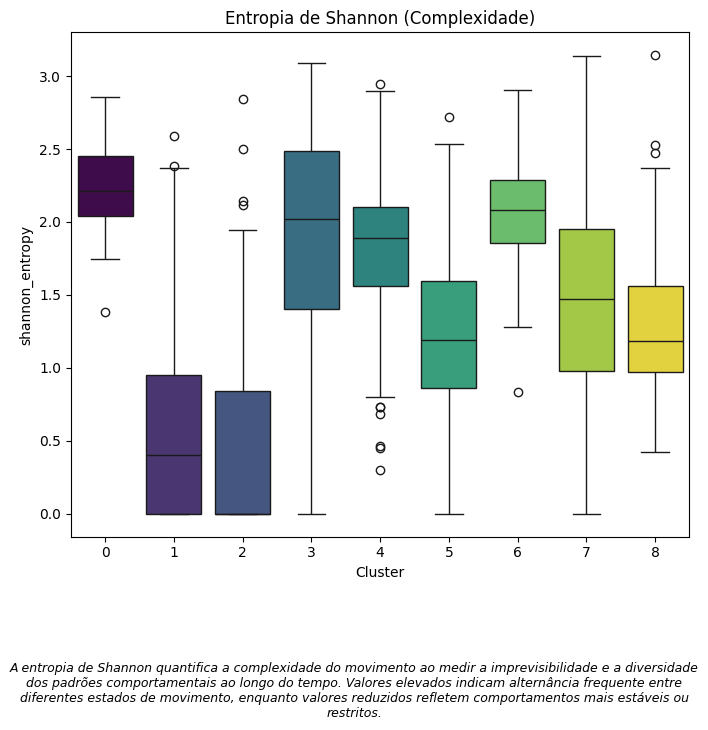

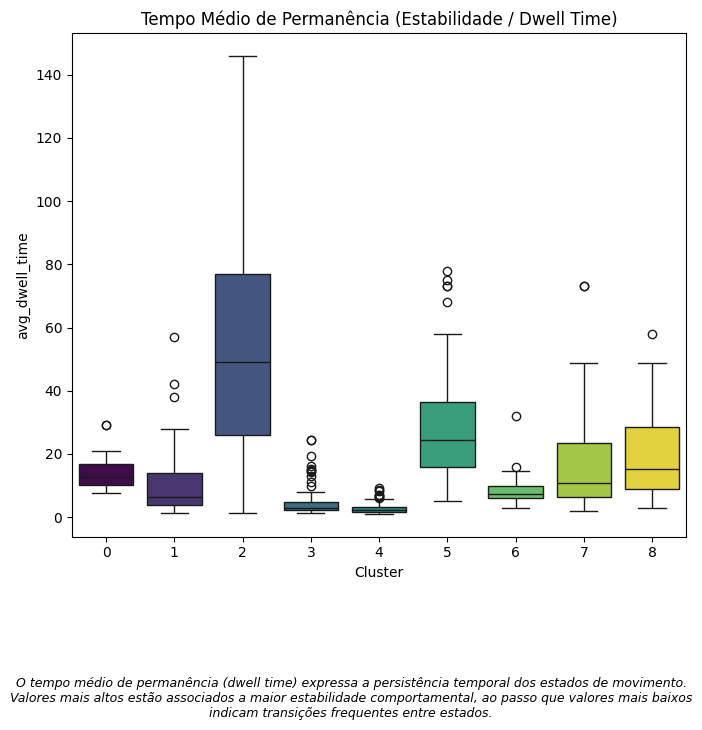

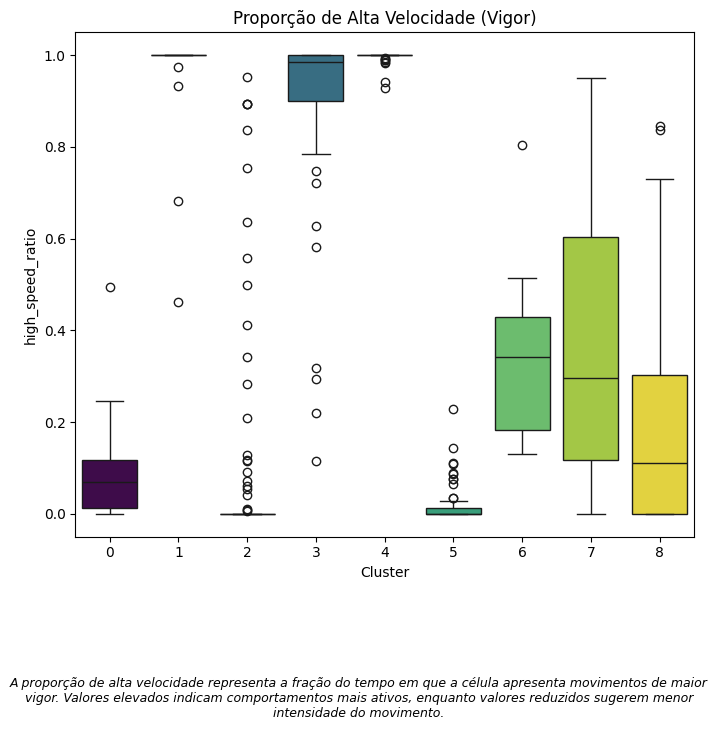

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = [
    (
        'shannon_entropy',
        'Entropia de Shannon (Complexidade)',
        'A entropia de Shannon quantifica a complexidade do movimento ao medir '
        'a imprevisibilidade e a diversidade dos padrões comportamentais ao '
        'longo do tempo. Valores elevados indicam alternância frequente entre '
        'diferentes estados de movimento, enquanto valores reduzidos refletem '
        'comportamentos mais estáveis ou restritos.'
    ),
    (
        'avg_dwell_time',
        'Tempo Médio de Permanência (Estabilidade / Dwell Time)',
        'O tempo médio de permanência (dwell time) expressa a persistência '
        'temporal dos estados de movimento. Valores mais altos estão associados '
        'a maior estabilidade comportamental, ao passo que valores mais baixos '
        'indicam transições frequentes entre estados.'
    ),
    (
        'high_speed_ratio',
        'Proporção de Alta Velocidade (Vigor)',
        'A proporção de alta velocidade representa a fração do tempo em que a '
        'célula apresenta movimentos de maior vigor. Valores elevados indicam '
        'comportamentos mais ativos, enquanto valores reduzidos sugerem menor '
        'intensidade do movimento.'
    )
]

for col, title, footnote in metrics:
    fig, ax = plt.subplots(figsize=(7, 6))

    sns.boxplot(
        data=df,
        x='cluster',
        y=col,
        hue='cluster',
        palette='viridis',
        ax=ax,
        legend=False
    )

    ax.set_title(title)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(col)

    # Rodapé refinado
    fig.text(
        0.5, -0.20,
        footnote,
        ha='center',
        fontsize=9,
        style='italic',
        wrap=True
    )

    plt.tight_layout()
    plt.show()


Visualização das Matrizes Médias (Heatmaps)

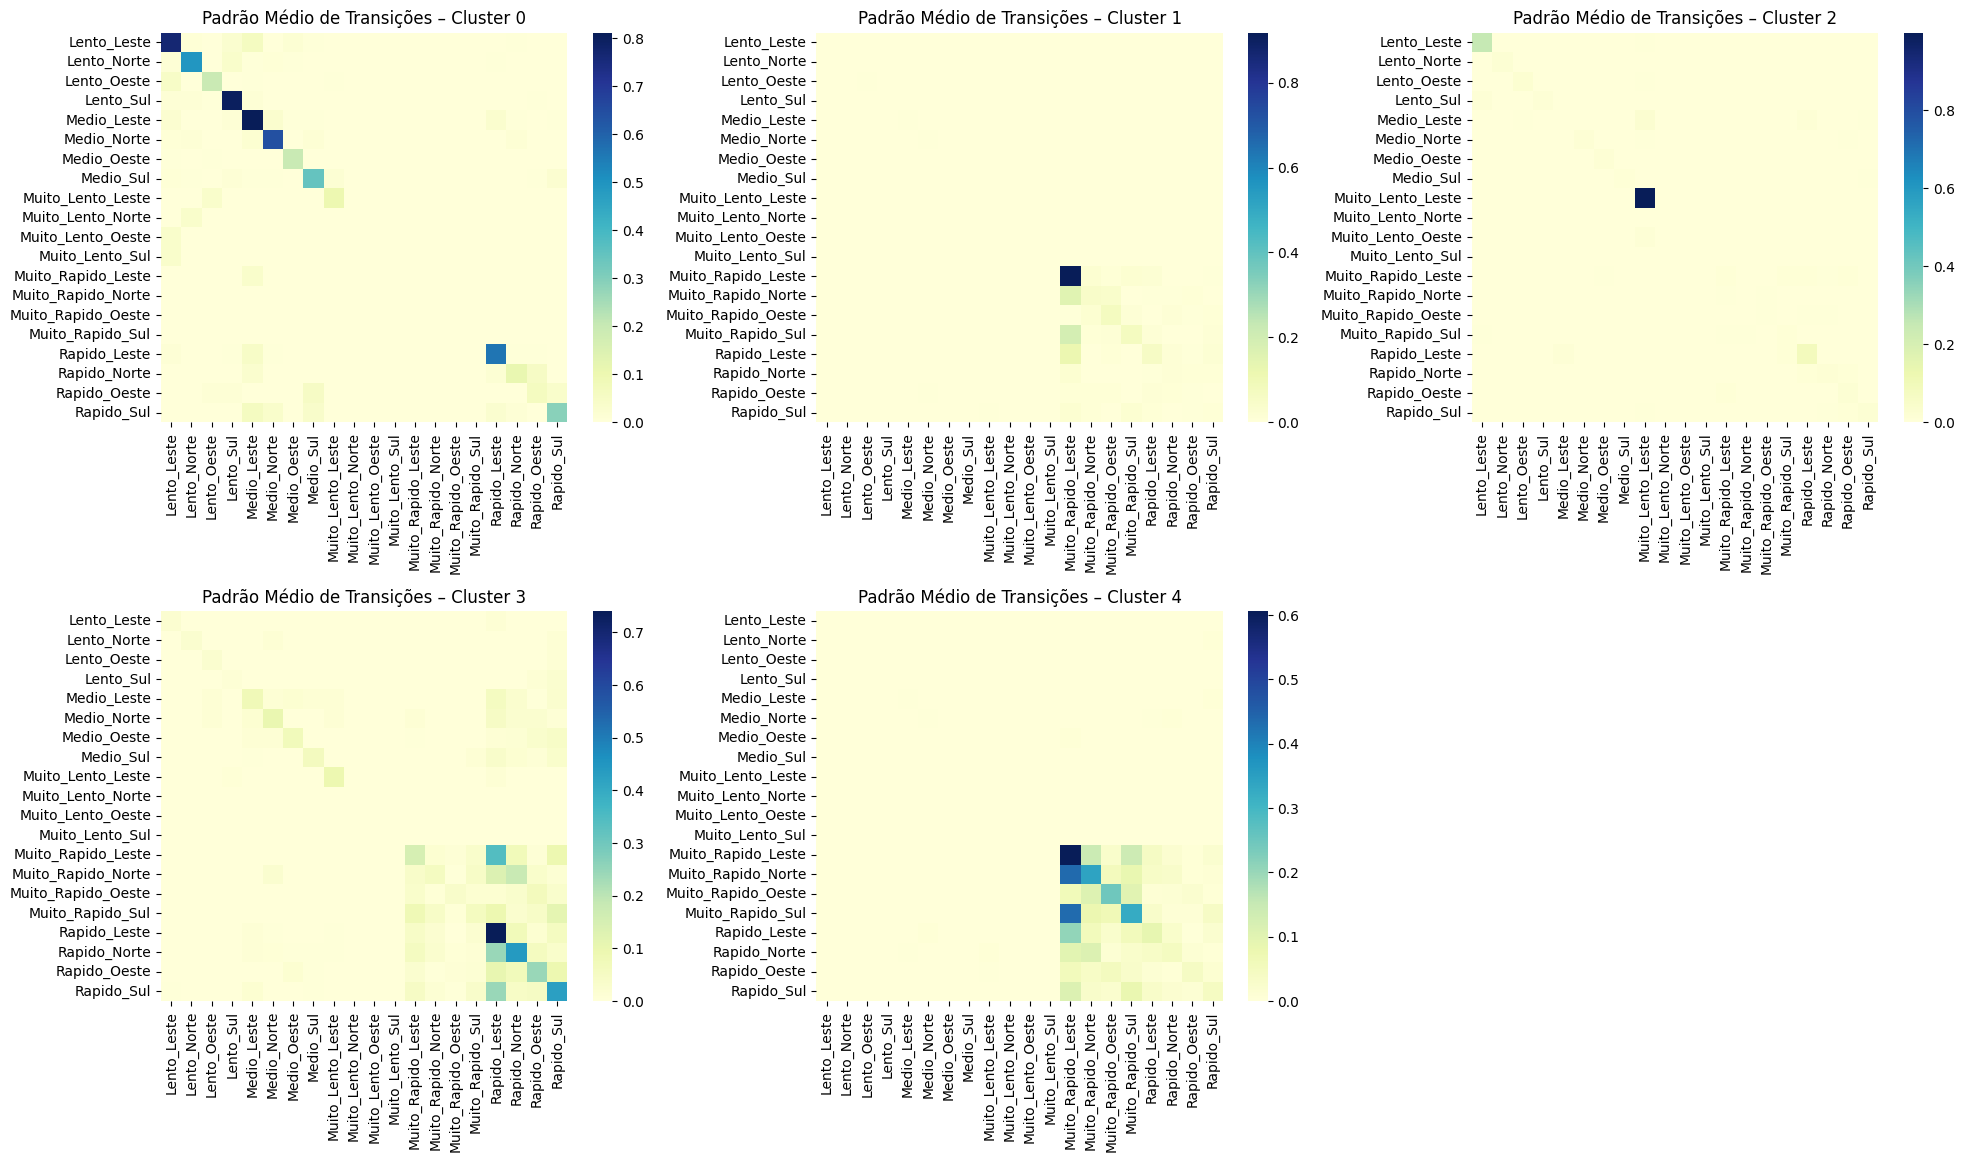

In [94]:
cluster_centers = kmeans.cluster_centers_
plt.figure(figsize=(20, 16))

for i in range(5):
    center_vec = cluster_centers[i]
    matrix = center_vec.reshape(n_states, n_states)
    
    plt.subplot(3, 3, i+1)
    sns.heatmap(matrix, xticklabels=unique_states, yticklabels=unique_states, cmap="YlGnBu")
    plt.title(f'Padrão Médio de Transições – Cluster {i}')

plt.tight_layout()
plt.show()

# Exportação dos resultados
df[['trajectory_id', 'cluster', 'pca_1', 'pca_2', 'tsne_1', 'tsne_2', 'umap_1', 'umap_2']].to_csv(DATA_CLUSTER/'01_trajectory_clusters.csv', index=False)

In [95]:
# =========================================================
# Construção das trajetórias transladada e rotacionada
# =========================================================

# Garante ordenação temporal correta
df_sorted = df_processed.sort_values(by=["trajectory_id", "timestamp"])

traj_df = (
    df_sorted
    .groupby("trajectory_id")
    .agg(
        trajectory_xy=("x", lambda s: list(zip(s, df_sorted.loc[s.index, "y"]))),
        trajectory_xy_translate=("x_translate", lambda s: list(zip(
            s, df_sorted.loc[s.index, "y_translate"]
        ))),
        trajectory_xy_rotated=("x_rotated", lambda s: list(zip(
            s, df_sorted.loc[s.index, "y_rotated"]
        )))
    )
    .reset_index()
)

# Junta com o dataframe original
df = df.merge(traj_df, on="trajectory_id", how="left")

df.to_csv("symbolicID.csv")

df["trajectory_label"] = [f"traj_{i}" for i in range(1, len(df) + 1)]

df.to_csv("symbolic.csv")


In [96]:
df.columns

Index(['trajectory_id', 'user_id', 'frame_inicial', 'frame_final',
       'symbolic_movement_10', 'symbolic_movement_15', 'symbolic_movement_20',
       'movement_list', 'cluster', 'shannon_entropy', 'avg_dwell_time',
       'high_speed_ratio', 'pca_1', 'pca_2', 'tsne_1', 'tsne_2', 'isomap_1',
       'isomap_2', 'mds_1', 'mds_2', 'nmf_1', 'nmf_2', 'umap_1', 'umap_2',
       'trajectory_xy', 'trajectory_xy_translate', 'trajectory_xy_rotated',
       'trajectory_label'],
      dtype='object')